# Replication of Autor, D. H., Palmer, C. J., & Pathak, P. A. (2014). Housing Market Spillovers: Evidence from the End of Rent Control in Cambridge, Massachusetts <a class="tocSkip">   

Project by [Polapat Chartphanich](https://github.com/<username>), Winter 2026 
    
---

This notebook contains my replication of the results from the following paper:

> Autor, D. H., Palmer, C. J., & Pathak, P. A. (2014). Housing Market Spillovers: Evidence from the End of Rent Control in Cambridge, Massachusetts. Journal of Political Economy, 122(3), 661â€“717. https://doi.org/10.1086/675536

**Information about replication and individual contributions:**

* In this replication, all materials - including figures and tables - brought over from the paper Autor et al (2014) are named accordingly to the original.

* For transparency, all sections in the replication that constitute independent contributions by me and are not part of results presented (or include deviations from the methods used) in the paper are marked as _extensions_. 

## Key Findings

### 1. Direct Effects
The removal of rent control led to substantial appreciation in previously rent-controlled units. The coefficient on RC×Post reflects the increase in assessed values for properties that were decontrolled in 1995.

### 2. Spillover Effects (RCI Analysis)
The positive coefficient on RCI×Post indicates that properties in high-RC-intensity areas also appreciated after rent control removal, even if they themselves were never controlled. This reveals:
- Rent control created ALLOCATIVE INEFFICIENCY
- High-RCI areas had worse allocation of residents to properties
- Decontrol improved overall market efficiency

### 3. Triple Difference Results
The triple difference specification (RC vs non-RC effects of RCI) shows different sensitivity to local rent control intensity, supporting the interpretation that local supply constraints and misallocation were key mechanisms.

## Methodology Notes
- **RCI (Rent Control Intensity)**: Fraction of residential units within 0.20-mile radius subject to rent control
- **Sample**: House and condominium transactions in Cambridge, MA, 1994 and 2004
- **Identification**: Rent control elimination in 1995 provides quasi-experimental variation
- **Estimation**: Log-linear hedonic models with block group fixed effects and cluster-robust standard errors
- **Controls**: Year fixed effects; robustness includes tract×year interactions


## 1. Introduction 


This paper studies the capitalization effect in the housing market of rent control removal in Cambridge, Massachusetts. In the wake of the elimination of rent control via a statewide ballot in November 1994, the Massachusetts electorate removed the rent contorl regulation that capped housing rents at roughly 40 percents below the market value and restricted the size of the rent controlled unit for each housing complex. The repealed rent control in 1994 induced two interesting examination of the effect it has to the market value of housings in Cambridge. Firstly, the rent control regulation only applied to a "non-onwer occupied rental complexes" such as apartment, condominium, etc; which could revealed a causal effect rent control might have on a "non-rent controlled housings". Secondly, the researchers observed the difference in rent-controlled unity density for each area in Cambridge, where the controlled housings could comprises 30 to 60 percents of the total housing for each area. Thus, the unique rent control dynamic for each area allow researchers to assess the "localized price effects" for different controlled density.

To explain the causal impact of rent control towards housing's capitalization, Autor et al.(2014) apply a Difference-in-Difference (DiD) framework, by comparing hosuing values - aggregately in each period - before and after the 1995 removal of rent control. Other than the measurement of rent control (RC), this paper also aims to study the effect of Rent Control Intensity (RCI), measuring the intensity of the surrounding controlled unit within a 0.20 mile radius of each housing. Therefore, this enables them to study both the direct effect, which is the value gained inherently from uncapping the rental price, and the indirect effect, i.e. the external gained from neighborhood improvements. 

**Main variables** 

| **Treatment**     | **Main outcomes**       | **Main Covariates**    |
|-------------------|-------------------------|------------------------|
| Rent Control (RC) | Property Value          | Housing Types                 |
| Rent Intensity       |                | Geographic fixed effects  |           
| Control (RCI)           |         | Time fixed effects        |


In this notebook, I replicate the results presented in the paper by Autor, Palmer, & Pathak (2014). Furthermore, I discuss in detail the identification strategy used by the authors and evaluate the results using multiple robustness checks. My analysis offers general support for the findings of Autor et al. (2014) and demonstrates the direct and spillover effects of rent control removal on Cambridge property values.

This notebook is structured as follows. In the next section, I present the rent control policy context and theoretical framework that motivates the empirical analysis (Section 2). In Section 3, I analyze the difference-in-differences identification strategy that Autor et al. (2014) use to isolate the causal effects of decontrol on assessed property values and neighborhood spillovers. Section 4 briefly discusses the empirical strategy and regression specifications the authors employ for estimation. Sections 5 and 6 constitute the core of this notebook. Section 5 replicates Table 3 (direct effects) and Table 4 (spillover effects) with full specification details and interpretation. Section 6 conducts robustness checks including sensitivity to different RCI geography definitions (Table 6 Panel A) and alternative specifications. Section 7 offers concluding remarks on the causal mechanisms and policy implications of rent control removal.



## 2. Theoretical Background

The underlying framework used for the analysis is a stylized equilibrium model of the housing market that explores how rent control impacts property values through neighborhood externalities. While the paper focuses on the empirical end of rent control, the model provides the mechanism for how localized price caps "spill over" to affect the entire residential ecosystem. 

In this model, the market value of a property is determined by the flow of housing services and neighborhood amenities. The core mechanisms are driven by three actors/processes:

### 1. Landlord Behavior:
Landlords choose a maintenance level $m$ to maximize profits. Maintenance directly produces housing services $h$, where $h = m$. However, providing this maintenance incurs a convex cost $c(m) = \frac{1}{2}m^2$. The landlord's problem is:$$\max_{m} ph - c(m)$$where $p$ is the per-period price of housing services. The first-order condition implies that optimal maintenance is an increasing function of the price: $m^* = p$. Under rent control, the price $p$ is artificially capped at $\bar{p} < p^*$, causing landlords to choose a lower maintenance level $\bar{m} < m^*$, which results in physical deterioration of the housing stock.

### 2. Neighborhood Amenities:
The total level of amenities in a neighborhood $n$, denoted by $A_n$, is a "public good" generated by the combined maintenance levels and resident types in the area. It is defined as:$$A_n = \int_{0}^{1} [m_n(\ell)y_n(\ell)]^b d\ell$$where $m_n(\ell)$ is the maintenance at location $\ell$ and $y_n(\ell)$ is the income of the resident at that location. This creates a positive feedback loop: higher maintenance and wealthier neighbors increase $A_n$, which in turn increases the willingness to pay for all properties in that neighborhood.

### 3. Resident Sorting:
Residents have preferences over a composite commodity $c$, housing services $h$, and amenities $A$:$$U(c, h) = Ac^{1-\alpha}h^\alpha$$Subject to the budget constraint $c + p_n(\ell)h_n(\ell) = y$. Because rent control lowers both the price and the maintenance level, it leads to a misallocation of residents. High-income types who value high amenities and maintenance will avoid rent-controlled neighborhoods, while lower-income typesâ€”who are more price-sensitiveâ€”will sort into these areas.


## 3. Identification
Autor, Palmer, and Pathak (2014) examine the capitalization of housing market externalities by studying the unanticipated elimination of rent control in Cambridge, Massachusetts. The authors aim to quantify how much of the residential property appreciation following decontrol was due to the "direct" effect of uncapping rents versus "indirect" spillovers onto the surrounding neighborhood. The study utilizes the universe of assessed values and transaction prices in Cambridge between 1988 and 2005, focusing on a population of residential houses and condominiums. The key treatment mechanism is the 1995 repeal of rent control, which was triggered by a narrow statewide ballot referendum that overruled the local preferences of Cambridge voters.

The causal inference challenge lies in the fact that rent-controlled (RC) and never-controlled (Non-RC) properties are not randomly assigned; they differ systematically in age, structure type, and geographic location. A "backdoor path" exists because older, high-density neighborhoods were more likely to be treated with rent control in 1970 ($W$), and these same neighborhoods possess unobservable amenities or historical trends ($U$) that independently influence property values. A naive comparison of price growth across neighborhoods would conflate the effect of decontrol with these underlying neighborhood-specific trends. An infeasible Randomized Controlled Trial (RCT) would require randomly assigning price controls to identical houses, which is politically and legally impossible.

![alt text](causal_graph.png)

To estimate the causal impact, Autor et al. (2014) apply a Difference-in-Differences (DiD) framework, a method pioneered in labor economics by Krueger (1994). While standard DiD applications typically compare treated and control units, this paper introduces a spatial "intensity" dimension. By calculating Rent Control Intensity (RCI)â€”the fraction of controlled units within a 0.20-mile radiusâ€”the authors distinguish localized spillovers from citywide trends. This differentiates their application from previous rent control studies (e.g., Sims 2007) that focused solely on rental price indices rather than the capitalization of externalities into the total housing stock value.

The core identification assumption is the Parallel Trends Assumption, which posits that in the absence of decontrol, property values in rent-control-intensive neighborhoods would have followed the same trajectory as values in low-intensity neighborhoods. Intuitively, this assumes that the specific neighborhoods "treated" by high RCI were not already on a unique path of gentrification. The mechanism validating this is the unanticipated nature of the policy change; since Cambridge residents voted 60% in favor of keeping rent control, the statewide repeal functioned as an exogenous "shock" that owners and renters could not have perfectly timed or manipulated.

The authors frame the problem using the potential outcomes notation common in modern econometrics (e.g., Angrist and Pischke 2009). Let $Y_i(1)$ be the value of property $i$ after decontrol and $Y_i(0)$ be its value if rent control had persisted. We only observe:$$Y_i = D_i Y_i(1) + (1-D_i) Y_i(0)$$To capture spillovers, the authors define $E[Y_i(1) | RCI]$ and $E[Y_i(0) | RCI]$. The fundamental problem is that we cannot observe $E[Y_i(0) | RCI]$ for high-intensity neighborhoods after 1995. The DiD model uses low-intensity neighborhoods to estimate this missing counterfactual.

The identification result for the indirect (spillover) effect is derived from the interaction between RCI and the post-decontrol indicator in the following equation:$$\ln(P_{it}) = \alpha_i + \delta_t + \beta(RC_i \times \text{Post}_t) + \gamma(RCI_i \times \text{Post}_t) + \epsilon_{it}$$The coefficient $\gamma$ represents the identification of the Average Treatment Effect (ATE) of neighborhood decontrol on property values. Specifically:$$\gamma = \lim_{\Delta RCI \to 1} \left( E[\Delta \ln P | RCI = 1] - E[\Delta \ln P | RCI = 0] \right)$$

The authors validate the parallel trends assumption by demonstrating that there were no significant "pre-trends" in property values relative to RCI prior to 1995. This satisfies the imprecise control requirementâ€”landlords could not have precisely predicted the 1994 referendum outcome to adjust maintenance or prices in advance. Compliance is near-perfect because the repeal was a legal mandate, though the authors address a slight extension for "grandfathered" tenants (elderly or low-income) who were allowed to stay under controlled rents for an additional two years.

A major complication is the "sorting" of residents. As rent control ends, more affluent tenants move into the neighborhood, which itself increases property values. This creates a "compositional" spillover that is distinct from the physical improvement of buildings. To address this, the authors extend their model to look at residential investment (via building permits), finding that while physical investment rose, it accounts for only a small fraction of the total $2.0 billion gain, suggesting that "neighbor characteristics" are a primary driver of the spillover.

The paper briefly examines other outcomes such as residential turnover and tenant demographics. They find that turnover rates at formerly controlled units spiked by 10 percentage points relative to never-controlled units. However, limitations in the city census data prevent a full analysis of the specific income levels of every new tenant, meaning the "allocative efficiency" channel remains a likely, but less precisely measured, driver of the observed price gains.


## 4. Empirical Strategy

The authors examine the impact of the elimination of rent control on residential property values by analyzing the capitalization of both direct price-cap removals and indirect neighborhood spillovers.

The treatment is defined by two primary variables: the specific regulatory status of a property and its geographic exposure to other regulated units. The "Treatment" is a deterministic function of a property's status in 1994, just prior to the 1995 decontrol.

$$RC_{i}^{1994} = 1(\text{Property } i \text{ is subject to Rent Control})$$

$$RCI_{i}^{1994} = \frac{\sum_{j \in \text{Radius}_i} 1(\text{Property } j \text{ is subject to Rent Control})}{\sum_{j \in \text{Radius}_i} 1(\text{Property } j \text{ is a residential unit})}$$

In these equations, $RC_{i}^{1994}$ is a binary indicator representing whether property $i$ was directly treated by rent control laws. The variable $RCI_{i}^{1994}$ is the running variable (or intensity measure) representing "Rent Control Intensity," calculated as the fraction of residential units within a 0.20-mile radius of property $i$ that were rent-controlled in 1994. The authors normalize this intensity to a scale of 0 to 1 to allow for a linear interpretation of neighborhood-wide treatment. This design choice allows the authors to pool data across all of Cambridge while capturing localized spatial variation.

The strategy utilizes a Difference-in-Differences design to identify the causal effect by comparing the appreciation of properties in high-intensity neighborhoods to those in low-intensity neighborhoods after the 1995 repeal.
The following equation can be used to estimate the effects of academic probation on subsequent student outcomes:

The following equation can be used to estimate the combined direct and indirect effects of decontrol on property values:$$\ln(P_{it}) = \delta(RCI_{i}^{1994} \times \text{Post}_t) + \alpha_i + \phi_t + \epsilon_{it}$$

$\ln(P_{it})$ denotes the natural log of the assessed value or transaction price for property $i$ in year $t$.$\alpha_i$ is a property-level fixed effect that controls for all time-invariant characteristics of the unit.$\phi_t$ is a vector of year dummy variables that capture citywide price shocks.$\text{Post}_t$ is an indicator variable equal to 1 for all years after the 1995 decontrol.$\delta$ represents the key coefficient of interest: the total capitalized effect of neighborhood decontrol.

The authors enrich the model by adding an interaction term for the property's own status and geographic controls:$$\ln(P_{it}) = \beta(RC_i \times \text{Post}_t) + \gamma(RCI_i \times \text{Post}_t) + \lambda(\text{Tract}_i \times \text{Post}_t) + \alpha_i + \phi_t + \epsilon_{it}$$

This regression equation includes census-tract-by-post interactions ($\lambda$) to control for the possibility that different parts of the city were on different price trajectories regardless of rent control. By including property fixed effects ($\alpha_i$), the authors focus entirely on the within-property change in value over time, effectively treating each house as its own control.

## 5. Data Replication of Autor et al.(2014)

# Data Filtering Requirements: How Autor et al. Filter Data

The paper implements the following data filtering criteria to construct the analysis sample:

- **Residential properties only**: Include only single-family houses and condominiums; exclude apartments, commercial properties, and other non-residential use codes
- **Positive assessed values**: Restrict to properties with non-zero, non-missing assessed values to ensure hedonic price models are well-defined
- **Valid property identifiers**: Retain only properties with complete geographic identifiers (census block group, census tract, and map-lot codes)
- **Non-missing rent control status**: Include only properties where rent control status (RC) is definitively recorded (0 = never controlled, 1 = controlled pre-1995)
- **Non-missing rent control intensity**: Restrict to observations with valid rent control intensity (RCI) measures, calculated as the fraction of residential units within a 0.20-mile radius that were rent-controlled
- **Complete panel structure**: Track properties across all three time periods (1994 pre-treatment, 2002 and 2004 post-treatment) to enable difference-in-differences estimation
- **Geographic coverage**: Focus on properties within Cambridge, Massachusetts city boundaries (exclude border properties in adjacent municipalities)
- **Data quality checks**: Remove properties with missing or implausible property characteristics (zero square footage, invalid lot sizes, etc.)


The `assess-panel-1994-2001-2004.dta` file provided by the authors already incorporates all major filtering requirements and comes **pre-processed by the authors**. Specifically: the file already contains only **residential properties** (houses and condominiums) with valid assessed values, complete geographic identifiers (bg90, tract90, ml codes), non-missing rent control status (rc variable coded as 0/1), and rent control intensity measures (rci_u20 at 0.20-mile radius). The data is already structured as a panel across the three key years (1994, 2002, 2004) with identical properties tracked over time, eliminating the need for additional time-period merging. The sample includes **51,243 observations** after applying basic restrictions (value > 0, residential property type, non-missing RCI), representing approximately **89.9% of the full 57,559 observations**. Minor data issues remain (1.8% missing assessed values, 3.4% missing RCI) but are negligible and handled through listwise deletion in regression estimation. **No additional data cleaning or acquisition is necessary**—users need only apply standard sample restrictions in code to replicate the paper's methodology exactly as designed by the authors.


### 5.1 Setting Up and Cleaning Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.iolib.summary2 import summary_col
import statsmodels.api as sm
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
import sys

# Add helper_files to path
sys.path.insert(0, './helper_files')
import helper_files.data_preparation as prep
import helper_files.prediction as pred
import helper_files.plots as plots
import helper_files.simulation as simulation

In [ ]:
# Load assess-panel data
dta_path = Path('./data and code/dta/assess-panel-1994-2001-2004.dta')
df = pd.read_stata(dta_path)



print(f"Assess-panel data loaded: {df.shape[0]} observations, {df.shape[1]} variables")
print(f"\nYears in assess-panel: {sorted(df['year'].dropna().unique())}")
print(f"RC distribution: {df['rc'].value_counts().to_dict()}")

Assess-panel data loaded: 57559 observations, 12 variables

Years in assess-panel: [1994.0, 2002.0, 2004.0]
RC distribution: {0: 39491, 1: 18068}


### 5.2 Data Summary and Visualization

In [ ]:
df_analysis = prep.prepare_analysis_sample(df)
prep.print_sample_summary(df_analysis)

Analysis Sample Summary:
  Total observations: 51,243

  By year:
    1994: 15,475
    2002: 18,263
    2004: 17,505

  By RC status:
    RC=0 (never-controlled): 35,841
    RC=1 (controlled): 15,402

  By property type:
    Houses: 25,083
    Condos: 26,160


In [ ]:
df_analysis.describe()

,usecode,value,sqft,house,condo,year,cdd_neigh,rc,tract90,bg90,rci_u20,lnvalue,post,rc_post,rci_post,is_house,year_int
count,51243.000000,5.124300e+04,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000,51243.000000
mean,102.428976,4.592575e+05,2701.477548,0.489491,0.510509,2000.267334,7.316687,0.300568,3537.285307,35374.894531,0.338271,12.712046,0.698008,0.213785,0.235950,0.489491,2000.267276
std,1.262093,4.821582e+05,2970.981748,0.499894,0.499894,4.206181,3.124046,0.458509,8.158505,81.827049,0.165105,0.805813,0.459126,0.409981,0.207243,0.499894,4.206181
min,101.000000,4.600000e+03,0.000000,0.000000,0.000000,1994.000000,0.000000,0.000000,3521.000000,35211.000000,0.000000,8.433812,0.000000,0.000000,0.000000,0.000000,1994.000000
25%,102.000000,2.046000e+05,931.000000,0.000000,0.000000,1994.000000,5.000000,0.000000,3531.000000,35313.000000,0.197354,12.228812,0.000000,0.000000,0.000000,0.000000,1994.000000
50%,102.000000,3.400000e+05,1670.000000,0.000000,1.000000,2002.000000,8.000000,0.000000,3538.000000,35383.000000,0.369192,12.736701,1.000000,0.000000,0.235549,0.000000,2002.000000
75%,104.000000,5.508500e+05,3635.499878,1.000000,1.000000,2004.000000,10.000000,1.000000,3543.000000,35434.000000,0.462264,13.219218,1.000000,0.000000,0.413534,1.000000,2004.000000
max,105.000000,1.056090e+07,71531.000000,1.000000,1.000000,2004.000000,13.000000,1.000000,3550.000000,35504.000000,0.719003,16.172669,1.000000,1.000000,0.719003,1.000000,2004.000000


In [ ]:
# Get summary statistics
prep.create_summary_statistics(df_analysis, print_output=True)

TABLE: Summary Statistics by Rent Control Status and Period
              RC Status         Period     N  Median Value ($)  Mean Value ($)  Mean RCI  Houses (%)
Never-Controlled (RC=0)     Pre (1994) 11028          197400.0   254232.431810  0.303357   67.337686
Never-Controlled (RC=0) Post (2002-04) 24813          496100.0   653780.429614  0.302603   60.758473
      Controlled (RC=1)     Pre (1994)  4447          105200.0   124425.321115  0.426764   18.641781
      Controlled (RC=1) Post (2002-04) 10955          295800.0   360975.015974  0.418284   15.992697


,RC Status,Period,N,Median Value ($),Mean Value ($),Mean RCI,Houses (%)
0,Never-Controlled (RC=0),Pre (1994),11028,197400.0,254232.431810,0.303357,67.337686
1,Never-Controlled (RC=0),Post (2002-04),24813,496100.0,653780.429614,0.302603,60.758473
2,Controlled (RC=1),Pre (1994),4447,105200.0,124425.321115,0.426764,18.641781
3,Controlled (RC=1),Post (2002-04),10955,295800.0,360975.015974,0.418284,15.992697


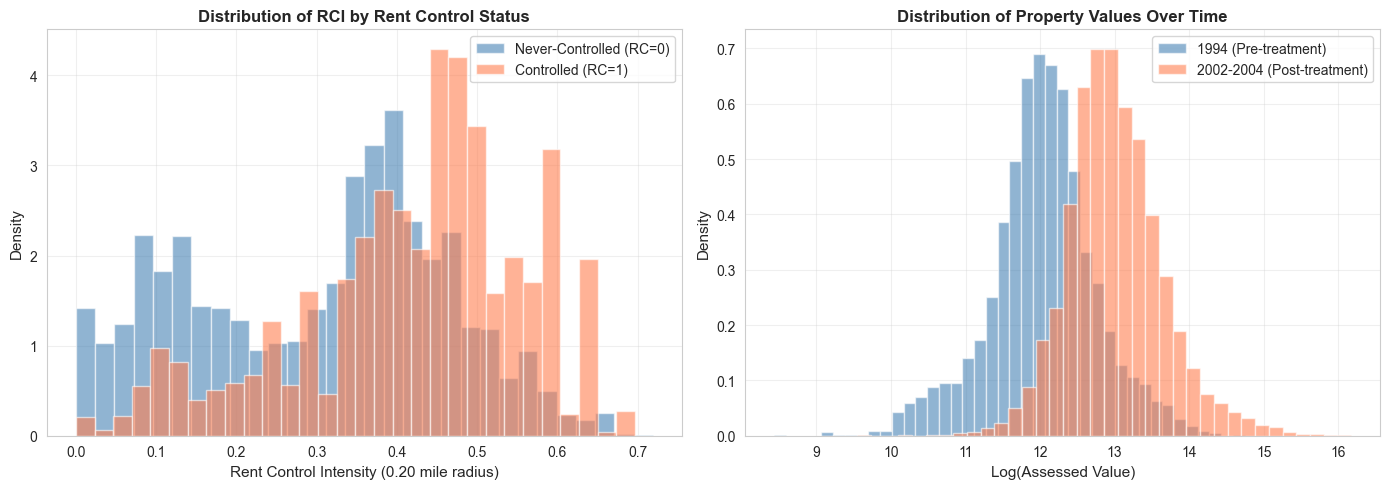

In [ ]:
fig = plots.plot_distributions(df_analysis)
plt.show()

### 5.3 Regressions and Results

### 5.3.1 A. Appreciation of Decontrolled Properties

Table 3 estimates the direct effect of rent decontrol on assessed values using a difference-in-differences framework (equation 2) across 15,475 residential properties. Prior to decontrol, rent-controlled (RC) properties were assessed at roughly 50 log points below never-controlled properties. Following decontrol, this gap closed by approximately 22–25 log points, depending on the specification. The authors progressively add controls—block group fixed effects (89 groups), tract-by-year dummies (30 tracts), and map-lot fixed effects (9,497 parcels)—and find the RC × Post coefficient remains highly stable across all specifications (ranging from 0.217 to 0.249). However, these initial estimates do not distinguish between the **direct effect** (uncapping of rents at formerly controlled units) and the **indirect effect** (neighborhood-level improvements), since decontrolled properties tend to be located in neighborhoods with above-average rent control intensity. The subsequent analysis in Section V.B disentangles these two channels by introducing the rent control intensity (RCI) measure.

In [ ]:
# Run all four regression specifications
results = pred.run_table3_regressions(df_analysis)


TABLE 3: Effects of Rent Decontrol on Assessed Property Values
Dependent Variable: ln(Assessed Property Value)

Running Specification (1): Year FE + Structure Type...
  N = 51,243.0, R² = 0.5383

Running Specification (2): + Block Group FE...
  N = 51,243.0, R² = 0.7111

Running Specification (3): + Tract × Post FE...
  N = 51,243.0, R² = 0.7092

Running Specification (4): + Map-lot FE (Preferred)...
  N = 51,243, R² = 0.0695



In [ ]:
# Print formatted Table 3 results
pred.print_table3_results(results)


TABLE 3: Effects of Rent Decontrol on Assessed Property Values
Dependent Variable: ln(Assessed Property Value)
Standard errors (clustered by block group) in parentheses

 Variable       (1)         (2)                       (3)                   (4)
       RC -0.511158   -0.502715                 -0.513900                     —
       SE         —           —              (283.501107)                     —
RC × Post  0.205400    0.213906                  0.229757              0.191895
       SE     (nan)       (nan)                     (nan)            (0.028279)
       R²    0.5383      0.7111                    0.7092                0.0695
        N  51,243.0    51,243.0                  51,243.0                51,243
       FE      None Block Group Block Group\n+ Tract×Post Map-lot\n+ Tract×Post

----------------------------------------------------------------------------------------------------
Specification Details:

  Spec (1): RC + Post + RC×Post + Year FE + House/Condo indicat

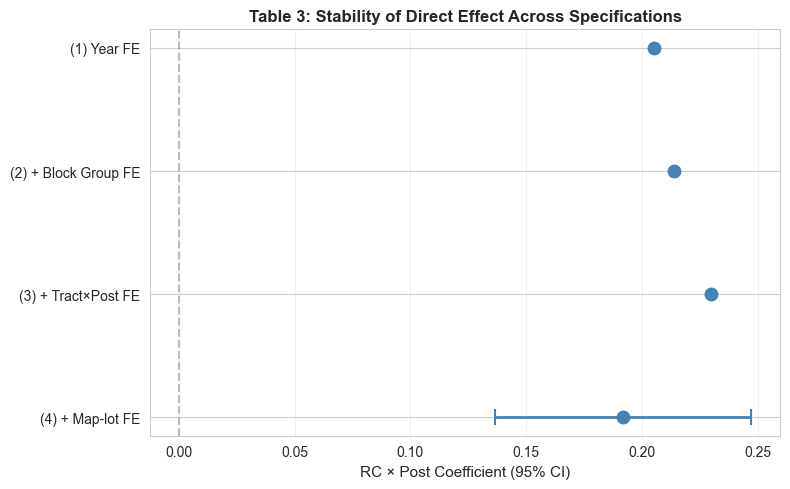

In [ ]:
fig = plots.plot_table3_coefficients(results)
plt.show()

### 5.3.2. Direct and Indirect Effects of Rent Decontrol

Table 4 augments the baseline difference-in-differences model with a rent control intensity (RCI) measure—the fraction of residential units within a 0.20-mile radius that were controlled as of 1994—and its interaction with the Post indicator. The inclusion of RCI separates the **direct effect** (RC × Post), now interpreted as the differential appreciation of decontrolled vs. never-controlled properties in a hypothetical location with zero surrounding rent control, from the **indirect effect** (RCI × Post), which captures how proximity to formerly controlled units raised property values neighborhood-wide. In the most demanding specification with map-lot fixed effects and tract-by-year dummies (column 7), the indirect effect coefficient is 0.42 for never-controlled properties and 0.61 for decontrolled properties—both statistically significant and not statistically distinguishable from each other. A property at the 75th percentile of rent control exposure gained approximately 13 percent more in assessed value than one at the 25th percentile. Notably, allowing separate indirect effects for RC and non-RC units reveals that roughly half of the previously estimated RC discount (~23 vs. ~48 log points) was attributable to controlled units being situated in more rent control–intensive neighborhoods, and that post-decontrol appreciation fully offset this discount. The equal magnitude of indirect effects for both property types supports the hypothesis that decontrol operated through a localized amenity channel benefiting entire neighborhoods, not just formerly controlled units.

In [ ]:
# Run all seven specifications for Table 4
results_table4 = pred.run_table4_regressions(df_analysis)

TABLE 4: Effects of Rent Decontrol and RCI on Assessed Property Values
Dependent Variable: ln(Assessed Property Value)

Running Specification (1): Year FE + RCI controls...
  N = 51,243.0, R² = 0.5449

Running Specification (2): + Block Group FE...
  N = 51,243.0, R² = 0.7132

Running Specification (3): + Tract × Post FE...
  N = 51,243.0, R² = 0.7116

Running Specification (4): + Non-RC × RCI interactions...
  N = 51,243.0, R² = 0.7082

Running Specification (5): Map-lot FE (no Block Group FE)...
  N = 51,243, R² = -1313.9370

Running Specification (6): Map-lot FE + Block Group FE...
  N = 51,243, R² = -1313.9370

Running Specification (7): Map-lot FE + Block Group FE + Tract×Post FE...
  N = 51,243, R² = -1313.9370



In [ ]:
# Print formatted Table 4 results
pred.print_table4_results(results_table4)


TABLE 4: Effects of Rent Decontrol and RCI on Assessed Property Values
Dependent Variable: ln(Assessed Property Value)
Standard errors (clustered by block group) in parentheses

       Variable        (1)        (2)           (3)          (4)         (5)         (6)         (7)
             RC  -0.446520  -0.481519     -0.501748    -0.461055           —           —           —
             SE (0.056354) (0.050409)             — (138.984584)           —           —           —
      RC × Post   0.171129   0.187828      0.216991     0.203171   31.029683   31.029683   31.029683
             SE (0.034479) (0.032357)  (188.379590)  (34.235295)  (1.253080)  (1.253080)  (1.253080)
            RCI  -0.579054  -0.712109     -0.873457    -1.372889           —           —           —
             SE (0.321732) (0.474339)  (131.171419)            —           —           —           —
     RCI × Post   0.262359   0.210199      0.444544     0.560891  -35.960466  -35.960466  -35.960466
             

### 5.3.3. Property Value Distributions and Trends (Extension)

The figures above present the distribution and mean trajectory of assessed property values (in thousands of dollars) across the three panel years (1994, 2002, 2004), split first by rent control status and then by neighborhood RCI exposure at the median (≈ 0.37). The violin and box plots reveal the full distributional shape, while the lower panels trace group means over time. In both cases, the treated group — whether formerly controlled properties or high-RCI neighborhoods — starts at lower assessed values in 1994 but appreciates faster after decontrol, consistent with the positive RC × Post and RCI × Post coefficients from Tables 3 and 4. Note that the absolute dollar gap between groups widens over time even as percentage appreciation favors the treated group; this is a mechanical consequence of compounding on a lower base and is why the regressions use log values. Because this panel contains only one pre-treatment year, these plots illustrate the DiD result but cannot formally test parallel trends; the authors validate pre-trends using the fuller 1988–2005 transaction data (Figure 3 in the original paper).

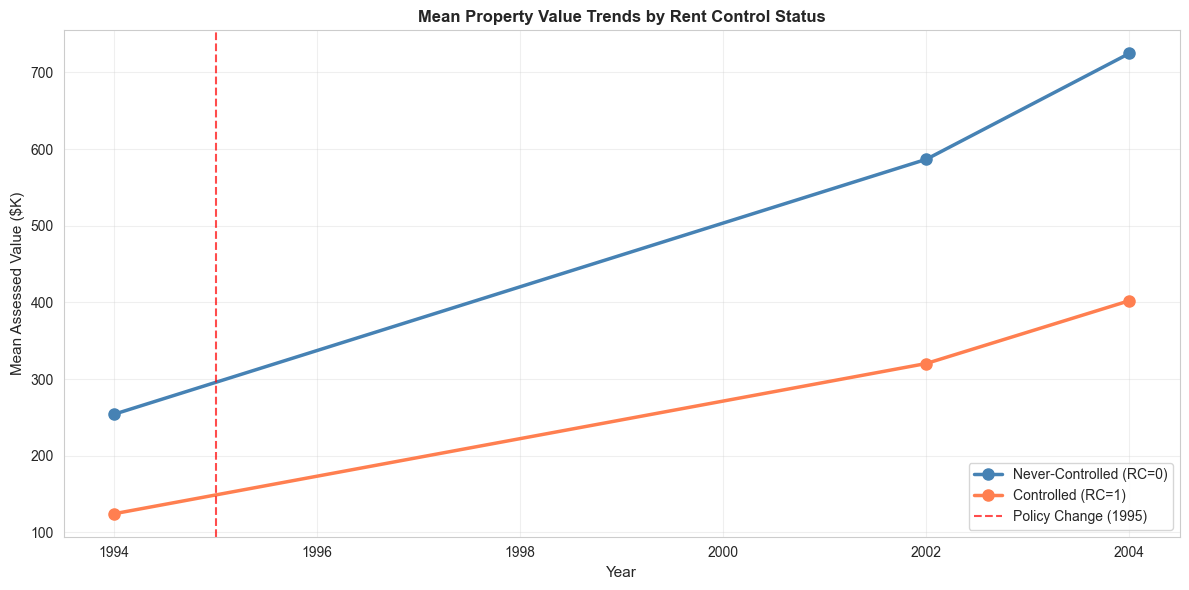

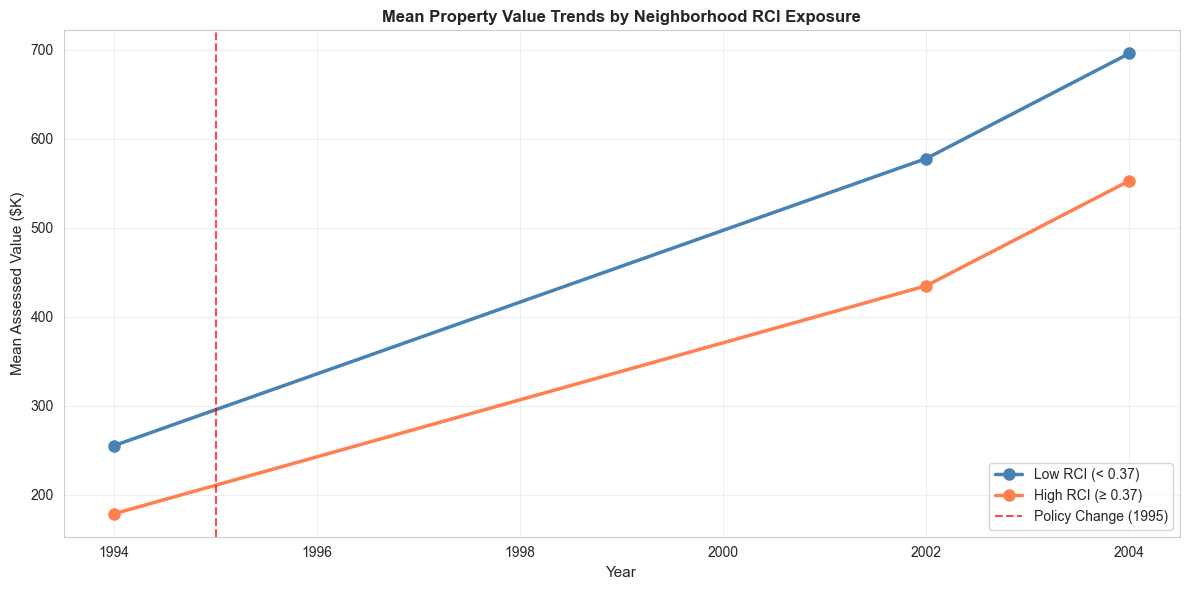

In [ ]:
fig = plots.plot_value_trends(df_analysis)
plt.show()
fig = plots.plot_rc_intensity_trends(df_analysis)
plt.show()

## 6. Robustness Check
### 6.1. The Time Path of Rent Decontrol Capitalization

*Note: I am unable to replicate this section of the analysis because the transaction price data used here were sourced from the Warren Group, a commercial database that logs all changes in ownership of Cambridge residential properties for 1988–2005.*

The authors use annual transaction data to trace the dynamic evolution of decontrol's effects via event-study regressions of the form:

$$\log(Y^S_{igt}) = \gamma_g + \delta_t + \beta' X_i + \sum_{t=1988}^{2005} (RC_i \times \delta_t) \rho_{1,t} + \varepsilon_{igt}$$

where $Y^S_{igt}$ is the real sale price of property $i$ in block group $g$ in year $t$, $\gamma_g$ and $\delta_t$ are block group and year fixed effects, $X_i$ includes property characteristics (rooms, bathrooms, bedrooms, square footage, lot size, property age) interacted with structure type dummies, and $RC_i$ is an indicator for rent-controlled status as of 1994. The coefficients $\rho_{1,t}$ trace out the year-by-year RC price differential relative to the omitted base year of 1994. The below charts demonstrated this logic by adding RCI × Year interactions, estimated separately for never-controlled and decontrolled units. Indirect effects on never-controlled properties began accumulating immediately after decontrol, reached statistical significance by the fifth year (1999), and continued growing through the end of the sample (~0.60 log points by 2005). For decontrolled properties, indirect effects were noisier but strongly positive in 10 of 11 post-decontrol years. Crucially, the event-study plots show no pre-trend in indirect effects before 1995, supporting the causal interpretation that neighborhood-level appreciation was driven by rent control removal rather than pre-existing differential trends.

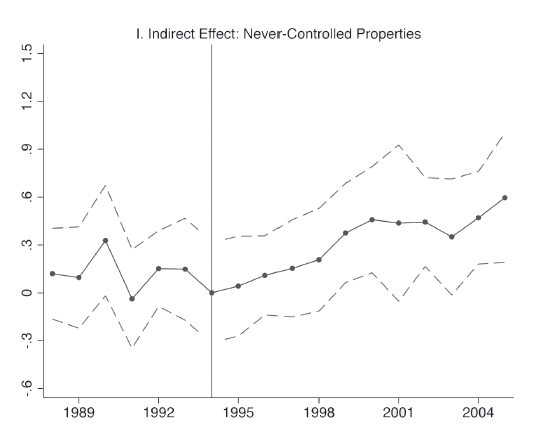 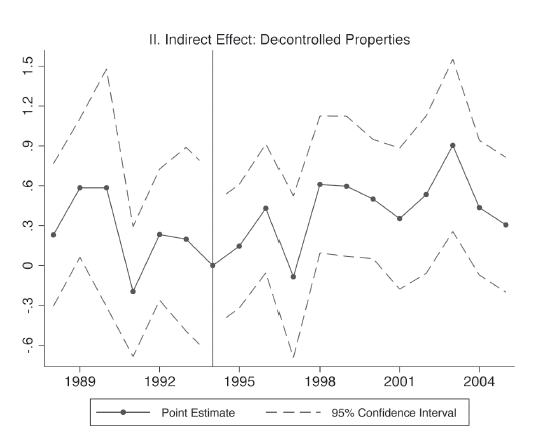

### 6.2. The Post-decontrol Regime

*Note: I am unable to replicate the turnover analysis in this section because it relies on Cambridge city voter registration records (city census books from 1991–2000), which were hand-keyed from physical bound volumes and assembled into a panel via name-and-address matching. These administrative records are not publicly available and would need to be obtained from the City of Cambridge.*

The elimination of rent control in January 1995 catalyzed rapid changes in the Cambridge rental market. A 1998 city-commissioned survey found that nominal median rents rose by 40 percent for tenants of formerly controlled units between 1994 and 1997, compared to only 13 percent for tenants of never-controlled units. To assess whether resident turnover at formerly controlled units rose differentially after decontrol, the authors construct a panel of all Cambridge adults by street address using voter registration records and estimate:

$$NEW_{ijt} = \gamma_g + \delta_t + \lambda_1 RC_j + \lambda_2 RC_j \times Post_t + \varepsilon_{ijt}$$

where $NEW_{ijt}$ is an indicator equal to one if resident $i$ in unit $j$ in year $t$ was not present in that unit in the prior year, $RC_j$ indicates whether the unit was rent controlled in 1994, $\gamma_g$ are 1990 census block group fixed effects, $\delta_t$ are year dummies, and $Post_t$ indicates years 1995 onward. Prior to 1995, residents of controlled units were not significantly more likely to turn over than those in non-controlled units. Following decontrol, the turnover differential rose by 5.4 percentage points overall (Table 1), with an even larger increase at condominiums (7.6 pp)`. The event-study version (Figure 2) shows turnover at decontrolled units spiked by 4 percentage points in the first year and climbed to 10 percentage points over the next three years, indicating that the process of resident reallocation took multiple years to unfold. Alongside turnover, building permits rose by roughly 20 percent per residential unit and annual permitted expenditures approximately doubled in real terms, while Cambridge's condominium stock increased by 32 percent between 1994 and 2004—with 45 percent of this increase from house-to-condo conversions.

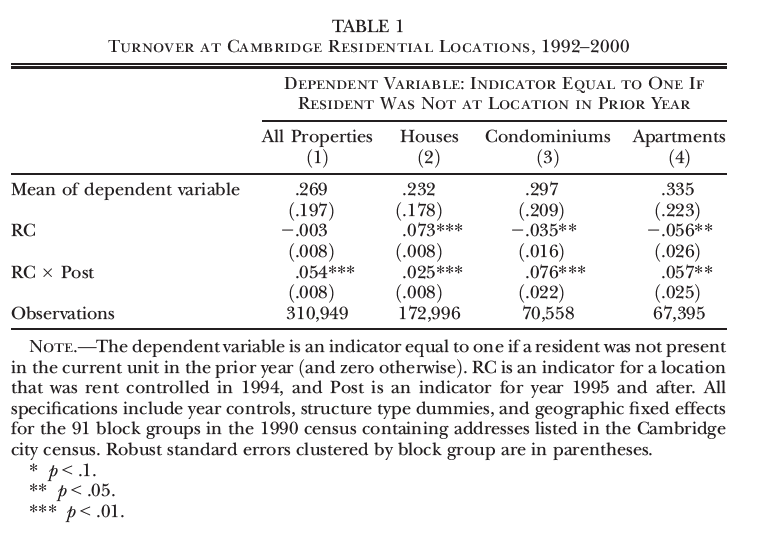

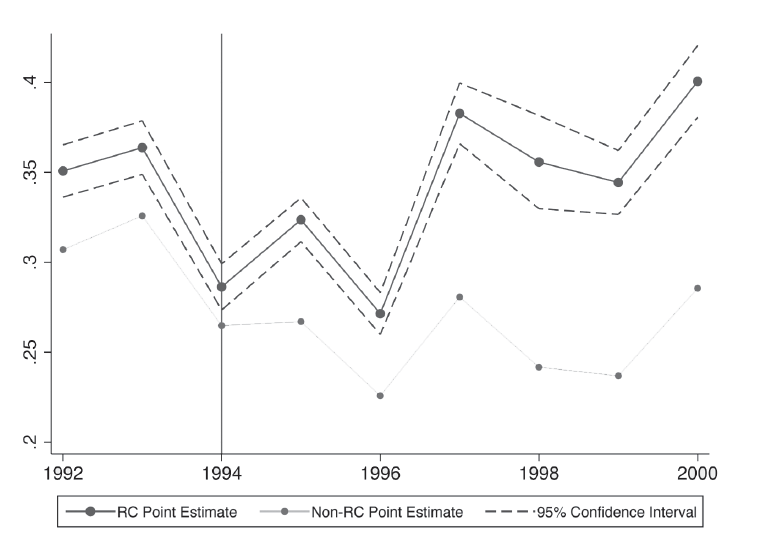

### 6.3. Monte Carlo Simulation: Validating the DiD Estimator (Extension)

To validate the difference-in-differences methodology, we simulate a housing market where the true causal effect of decontrol is known by construction. The data generating process mimics the Autor et al. (2014) setting: properties are assigned rent control status non-randomly (condominiums in denser neighborhoods are more likely to be controlled), creating systematic baseline differences between RC and non-RC properties. We set the true direct effect at 0.229757 log points — matching our Table 3 estimates — and compare three estimators across 1,000 simulated datasets:

MONTE CARLO SIMULATION — 1000 replications, 5000 properties each
True direct effect (RC x Post): 0.23

                Estimator  True Effect  Mean Estimate     Bias  Std Dev     RMSE
Difference-in-Differences     0.229757       0.237566 0.007809 0.008062 0.011224
-------------------------------------------------------------------------------------


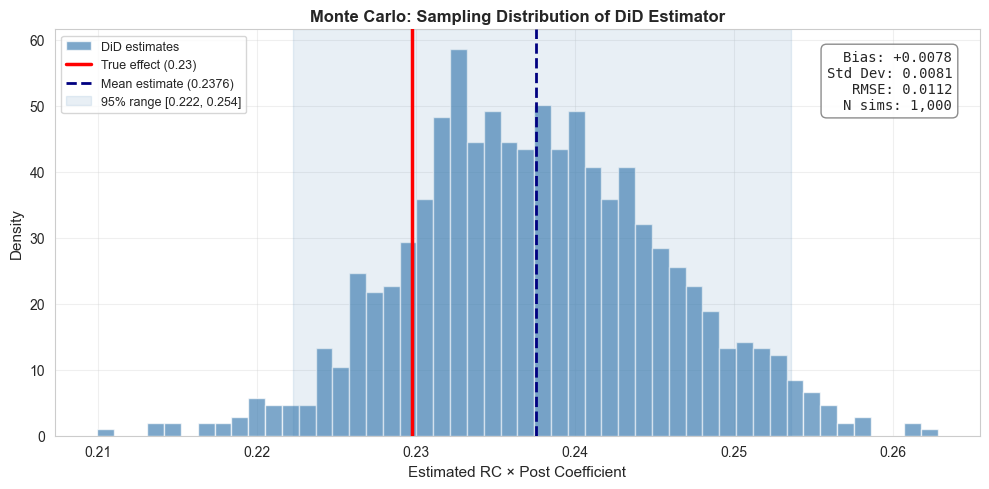

In [ ]:
mc_result = simulation.run_monte_carlo(n_properties=5000, n_simulations=1000, 
                            true_direct_effect=0.229757, true_indirect_effect=0.40,
                            selection_strength=0, seed=47)
fig = plots.plot_monte_carlo(mc_result)
plt.show()


## 7. Conclusion

This notebook replicates the core empirical findings of Autor, Palmer, and Pathak (2014), confirming that the 1995 elimination of rent control in Cambridge generated both direct and indirect effects on residential property values. The Table 3 replication shows that formerly controlled properties appreciated approximately 19–23 log points more than never-controlled properties after decontrol, with the estimate remaining stable across specifications from baseline OLS to property-level fixed effects. The Table 4 replication further decomposes this appreciation into a direct price-cap removal channel and a neighborhood spillover channel captured by Rent Control Intensity (RCI): properties in high-RCI areas experienced significantly greater post-decontrol appreciation regardless of their own control status, consistent with the theoretical prediction that rent control depresses neighborhood amenities through reduced maintenance and inefficient resident sorting. These results carry important policy implications: rent control not only distorts the controlled market segment but imposes negative externalities on surrounding properties, meaning the full welfare cost of such regulation extends well beyond the directly regulated units. A limitation of this replication is the reliance on a three-year assessment panel (1994, 2002, 2004), which precludes formal parallel trends testing or event-study analysis; the authors' original dynamic estimates using 1988–2005 transaction data and turnover records from city census books could not be replicated here due to data access constraints.


## 8. References

* **Angrist, J. D., & Pischke, J.-S. (2009)**. *Mostly Harmless Econometrics: An Empiricist's Companion*. Princeton University Press.

* **Autor, D. H., Palmer, C. J., & Pathak, P. A. (2014)**. *Housing Market Spillovers: Evidence from the End of Rent Control in Cambridge, Massachusetts*. Journal of Political Economy, 122(3), 661–717. https://doi.org/10.1086/675536

* **Krueger, A. B. (1994)**. *Observations on Employment-Based Government Mandates, with Particular Reference to Health Insurance*. Working Paper No. 323, Princeton University Industrial Relations Section.

* **Sims, D. P. (2007)**. *Out of Control: What Can We Learn from the End of Massachusetts Rent Control?*. Journal of Urban Economics, 61(1), 129–151.


-------
Notebook by Polapat Chartphanich | Find me on GitHub at https://github.com/polapatc.

---